# EDA: `train`, `benchmark_items`, `benchmark_queries`

Разведочный анализ датасетов пар **«поисковый запрос → объявление»** (маркетплейс-задача поиска/ранжирования).

| файл | что содержит |
|---|---|
| `train.parquet` | обучающие пары: параметры запроса + признаки объявления (≈500 тыс. строк) |
| `benchmark_items.parquet` | каталог товаров бенчмарка (≈189 тыс. объявлений) |
| `benchmark_queries.parquet` | запросы бенчмарка (2 452 строки, есть `query_id`) |

**Что внутри ноутбука:** схемы и пропуски, длины и топы запросов, параметры поиска (`infm_params_text`), цены (с аномалиями), рейтинги и отзывы, гео, категории, длины текстов и n-граммы, структура пар (сколько объявлений на запрос), дубликаты, пересечение benchmark↔train, корреляции, авто-сводка выводов.

**Зависимости:** `pandas`, `pyarrow`, `numpy`, `matplotlib`. Если запускаете в другом месте — поменяйте пути в `FILES` ниже.

> Совет: сначала **Run All**. Тяжёлые ячейки (чтение `train`, n-граммы) выполняются 1–3 минуты.

In [1]:
import os, re, gc, warnings
from collections import Counter

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
print('pandas', pd.__version__, '| numpy', np.__version__,
      '| matplotlib', matplotlib.__version__, '| pyarrow', pq.__version__ if hasattr(pq, "__version__") else __import__("pyarrow").__version__)

pandas 2.3.2 | numpy 2.3.4 | matplotlib 3.10.6 | pyarrow 22.0.0


In [2]:
# === ПУТИ К ФАЙЛАМ — поменяйте при необходимости ===
FILES = {
    'train':             r'train.parquet',
    'benchmark_items':   r'benchmark_items.parquet',
    'benchmark_queries': r'benchmark_queries.parquet',
}

for name, path in FILES.items():
    assert os.path.exists(path), f'файл не найден: {path}'
    pf = pq.ParquetFile(path)
    print(f'{name:20s} {os.path.getsize(path)/1e6:9.1f} MB | {pf.metadata.num_rows:>7d} строк | '
          f'{pf.metadata.num_columns:>2d} колонок | {pf.metadata.num_row_groups} row groups')

train                    490.2 MB |  497673 строк | 19 колонок | 1 row groups
benchmark_items          195.7 MB |  189212 строк | 14 колонок | 1 row groups
benchmark_queries          0.1 MB |    2452 строк |  6 колонок | 1 row groups


## 1. Загрузка и производные признаки
`train` читается целиком (≈0.5 GB parquet, в памяти ~1–2 GB). Если памяти мало — задайте `TRAIN_SAMPLE_ROWS`.

In [3]:
TRAIN_SAMPLE_ROWS = None   # например 200_000, чтобы ускорить работу на слабой машине

bm_queries = pd.read_parquet(FILES['benchmark_queries'])
bm_items   = pd.read_parquet(FILES['benchmark_items'])
train      = pd.read_parquet(FILES['train'])

if TRAIN_SAMPLE_ROWS and len(train) > TRAIN_SAMPLE_ROWS:
    train = train.sample(TRAIN_SAMPLE_ROWS, random_state=42).reset_index(drop=True)

# decimal -> float для анализа
for df in (bm_items, train):
    df['item_price_f'] = df['item_price'].astype('float64')
    df['item_lat_f']   = df['item_latitude'].astype('float64')
    df['item_lon_f']   = df['item_longitude'].astype('float64')
    df['title_len']    = df['item_title_raw'].str.len()
    df['desc_len']     = df['item_description_raw'].str.len()

train['query_len_chars'] = train['search_query'].str.len()
train['query_len_words'] = train['search_query'].str.split().str.len()
bm_queries['query_len_chars'] = bm_queries['search_query'].str.len()
bm_queries['query_len_words'] = bm_queries['search_query'].str.split().str.len()

# ключ группы запроса: одинаковый текст + локация + категория + флаги + параметры
GROUP_COLS = ['search_query', 'search_location_id', 'search_category',
              'search_is_delivery_search', 'search_infm_params_text']

print('train:', train.shape, '| benchmark_items:', bm_items.shape, '| benchmark_queries:', bm_queries.shape)

train: (497673, 26) | benchmark_items: (189212, 19) | benchmark_queries: (2452, 8)


## 2. Обзор: размер, память, пропуски, дубликаты

In [4]:
def overview(name, df):
    n_cells = df.size
    return {
        'файл': name,
        'строк': len(df),
        'колонок': df.shape[1],
        'память, МБ': round(df.memory_usage(deep=True).sum() / 1e6, 1),
        '% пропущенных ячеек': round(100 * df.isna().sum().sum() / n_cells, 3),
        'полных дублей строк': int(df.duplicated().sum()),
    }

pd.DataFrame([overview(n, d) for n, d in
              [('train', train), ('benchmark_items', bm_items), ('benchmark_queries', bm_queries)]])

,файл,строк,колонок,"память, МБ",% пропущенных ячеек,полных дублей строк
0,train,497673,26,3876.1,0.367,30619
1,benchmark_items,189212,19,1445.2,0.816,0
2,benchmark_queries,2452,8,0.7,0.000,0


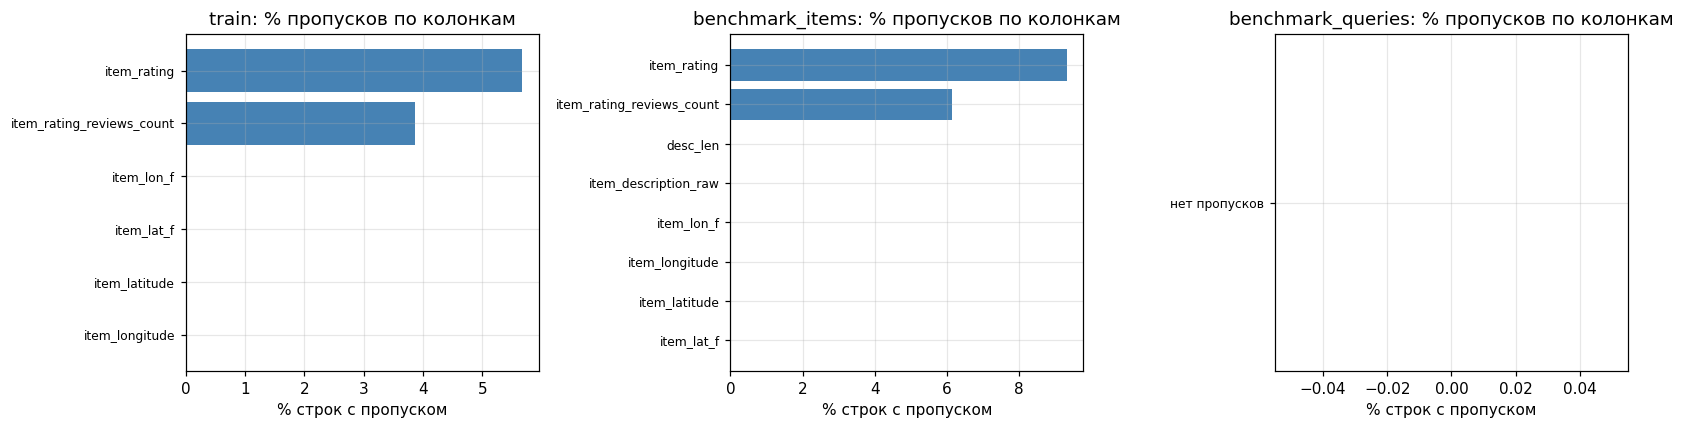

Пропуски train: {'item_rating_reviews_count': 19211, 'item_rating': 28232, 'item_longitude': 4, 'item_latitude': 4, 'item_lat_f': 4, 'item_lon_f': 4}
Пропуски benchmark_items: {'item_rating_reviews_count': 11615, 'item_rating': 17631, 'item_longitude': 1, 'item_latitude': 1, 'item_description_raw': 35, 'item_lat_f': 1, 'item_lon_f': 1, 'desc_len': 35}
Пропуски benchmark_queries: {}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('train', train),
                                 ('benchmark_items', bm_items),
                                 ('benchmark_queries', bm_queries)]):
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        miss = pd.Series({'нет пропусков': 0.0})
    ax.barh(range(len(miss)), miss.values, color='steelblue')
    ax.set_yticks(range(len(miss)))
    ax.set_yticklabels(miss.index, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'{name}: % пропусков по колонкам')
    ax.set_xlabel('% строк с пропуском')
plt.tight_layout(); plt.show()

print('Пропуски train:', train.isna().sum()[train.isna().sum() > 0].to_dict())
print('Пропуски benchmark_items:', bm_items.isna().sum()[bm_items.isna().sum() > 0].to_dict())
print('Пропуски benchmark_queries:', bm_queries.isna().sum()[bm_queries.isna().sum() > 0].to_dict())

In [6]:
for name, df in [('train', train), ('benchmark_items', bm_items), ('benchmark_queries', bm_queries)]:
    print('=' * 70)
    print(name)
    info = pd.DataFrame({'dtype': df.dtypes.astype(str), 'не-NaN': df.notna().sum()})
    info['уникальных'] = [df[c].nunique(dropna=True) for c in df.columns]
    display(info)

train


,dtype,не-NaN,уникальных
search_query,object,497673,74529
search_location_id,int64,497673,2782
search_is_delivery_search,int32,497673,2
search_infm_params_text,object,497673,3724
search_category,int64,497673,4
item_title_raw,object,497673,210029
item_rating_reviews_count,float64,478462,1372
item_rating,float64,469441,8832
item_price,object,497673,2992
item_microcat_id,int64,497673,212


benchmark_items


,dtype,не-NaN,уникальных
item_title_raw,object,189212,119952
item_rating_reviews_count,float64,177597,1170
item_rating,float64,171581,6007
item_price,object,189212,2949
item_microcat_id,int64,189212,752
item_longitude,object,189211,120004
item_location_id,int64,189212,2877
item_latitude,object,189211,119778
item_is_phone_hidden,bool,189212,2
item_is_message_forbidden,bool,189212,2


benchmark_queries


,dtype,не-NaN,уникальных
query_id,object,2452,2452
search_query,object,2452,2452
search_location_id,int64,2452,273
search_is_delivery_search,int32,2452,1
search_infm_params_text,object,2452,132
search_category,int64,2452,2
query_len_chars,int64,2452,59
query_len_words,int64,2452,10


## 3. Поисковые запросы

Длины, частотность, параметры поиска (`search_infm_params_text`), категория/локация/доставка.

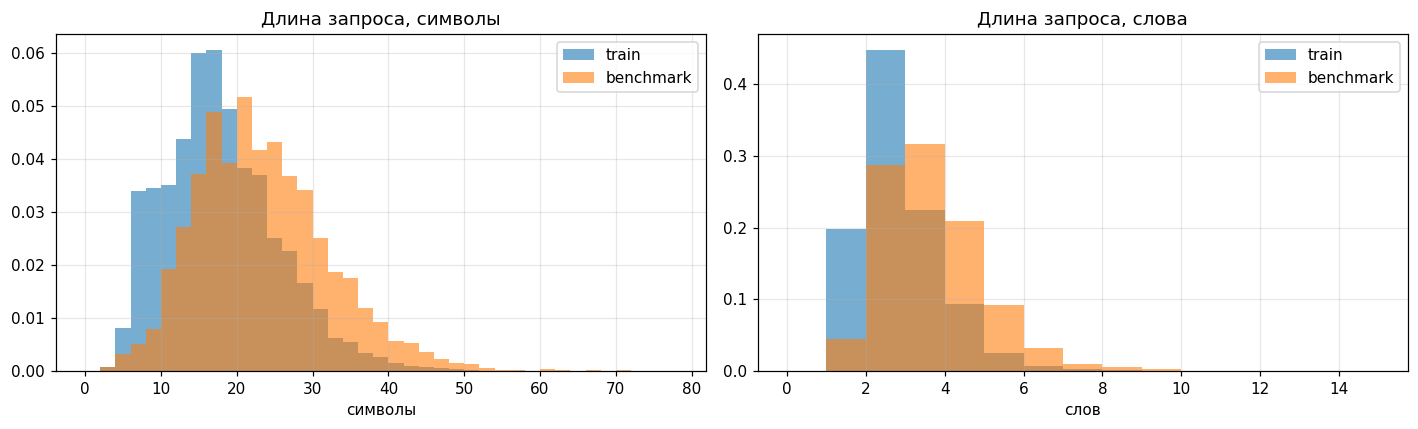

train, символы: {'count': 497673.0, 'mean': 17.5, 'std': 7.6, 'min': 1.0, '25%': 12.0, '50%': 17.0, '75%': 22.0, 'max': 113.0}
benchmark, символы: {'count': 2452.0, 'mean': 23.0, 'std': 8.9, 'min': 2.0, '25%': 17.0, '50%': 22.0, '75%': 28.0, 'max': 70.0}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins_c = np.arange(0, 80, 2)
axes[0].hist(train['query_len_chars'], bins=bins_c, alpha=.6, label='train', density=True)
axes[0].hist(bm_queries['query_len_chars'], bins=bins_c, alpha=.6, label='benchmark', density=True)
axes[0].set_title('Длина запроса, символы'); axes[0].set_xlabel('символы'); axes[0].legend()

bins_w = np.arange(0, 16, 1)
axes[1].hist(train['query_len_words'], bins=bins_w, alpha=.6, label='train', density=True)
axes[1].hist(bm_queries['query_len_words'], bins=bins_w, alpha=.6, label='benchmark', density=True)
axes[1].set_title('Длина запроса, слова'); axes[1].set_xlabel('слов'); axes[1].legend()
plt.tight_layout(); plt.show()

print('train, символы:', train['query_len_chars'].describe().round(1).to_dict())
print('benchmark, символы:', bm_queries['query_len_chars'].describe().round(1).to_dict())

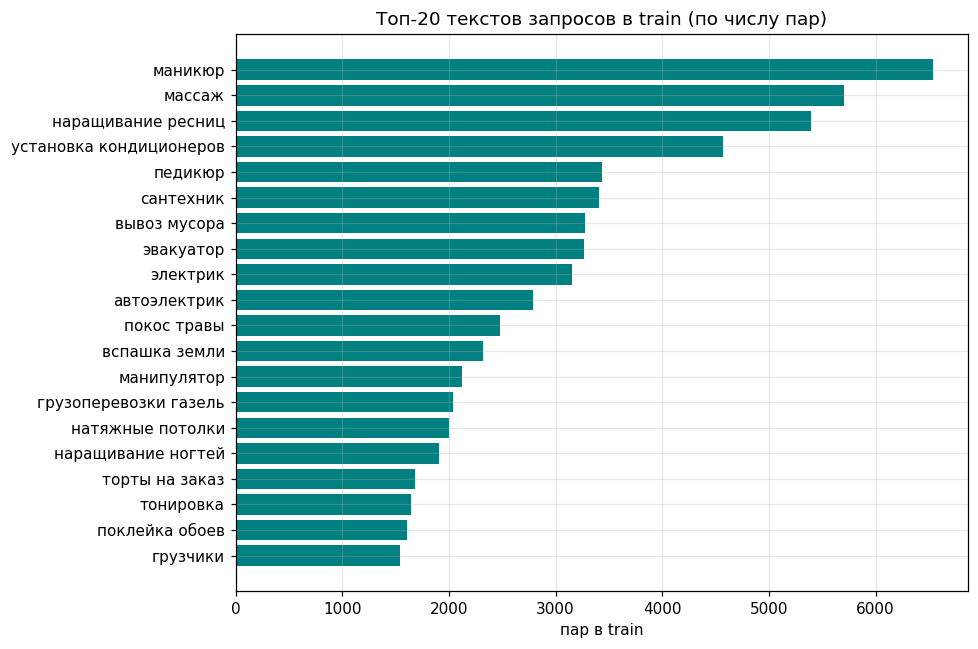

Уникальных текстов запросов: train = 74529 | benchmark = 2452
Повторяющиеся тексты в benchmark_queries (разные query_id): 0


In [8]:
top = train['search_query'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([q[:45] for q in top.index][::-1], top.values[::-1], color='teal')
ax.set_title('Топ-20 текстов запросов в train (по числу пар)')
ax.set_xlabel('пар в train')
plt.tight_layout(); plt.show()

print('Уникальных текстов запросов: train =', train['search_query'].nunique(),
      '| benchmark =', bm_queries['search_query'].nunique())
print('Повторяющиеся тексты в benchmark_queries (разные query_id):',
      int(bm_queries['search_query'].duplicated().sum()))

доля запросов с параметрами: train = 67.0% | benchmark = 36.9%


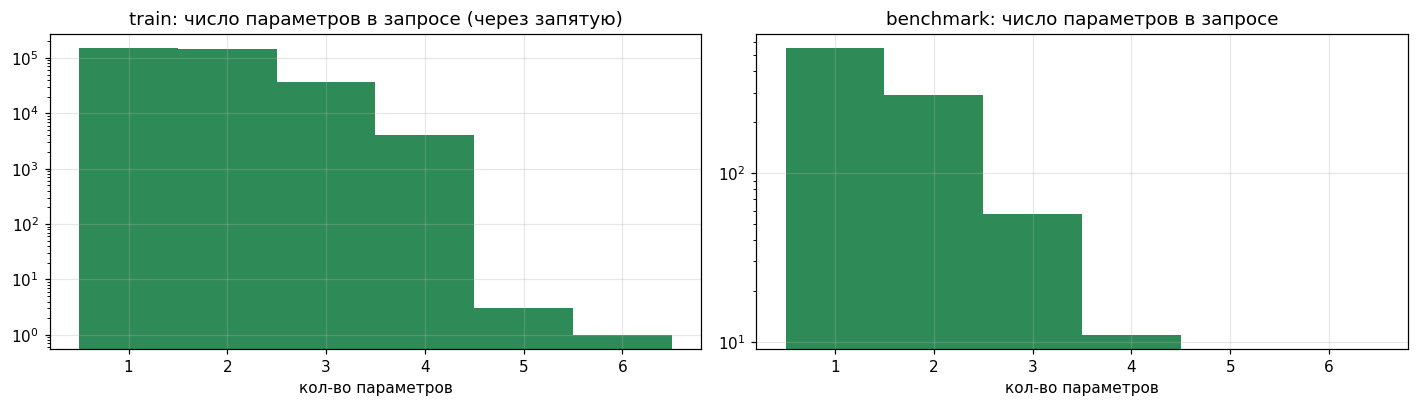

Топ-10 строк параметров в benchmark_queries:


,запросов
search_infm_params_text,
Вид услуги,60
"Вид услуги Оборудование, производство",53
Вид услуги Ремонт и отделка,48
"Вид услуги Праздники, мероприятия",40
"Вид услуги Обучение, курсы",39
"Вид услуги Красота, здоровье",36
Вид услуги Вывоз мусора и вторсырья,36
Вид услуги Грузоперевозки,31
"Тип услуги Услуги парикмахера Вид услуги Красота, здоровье",26


In [9]:
def param_parts(s):
    s = s.fillna('').astype(str).str.strip()
    has = s != ''
    parts = s[has].str.split(',').str.len()
    return has, parts

tr_has, tr_parts = param_parts(train['search_infm_params_text'])
bq_has, bq_parts = param_parts(bm_queries['search_infm_params_text'])
print(f'доля запросов с параметрами: train = {100*tr_has.mean():.1f}% | benchmark = {100*bq_has.mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
m = max(tr_parts.max(), bq_parts.max())
bins_p = np.arange(0.5, m + 1.5, 1)
axes[0].hist(tr_parts, bins=bins_p, color='seagreen', log=True)
axes[0].set_title('train: число параметров в запросе (через запятую)')
axes[1].hist(bq_parts, bins=bins_p, color='seagreen', log=True)
axes[1].set_title('benchmark: число параметров в запросе')
for ax in axes: ax.set_xlabel('кол-во параметров')
plt.tight_layout(); plt.show()

print('Топ-10 строк параметров в benchmark_queries:')
display(bm_queries.loc[bq_has, 'search_infm_params_text'].value_counts().head(10).to_frame('запросов'))

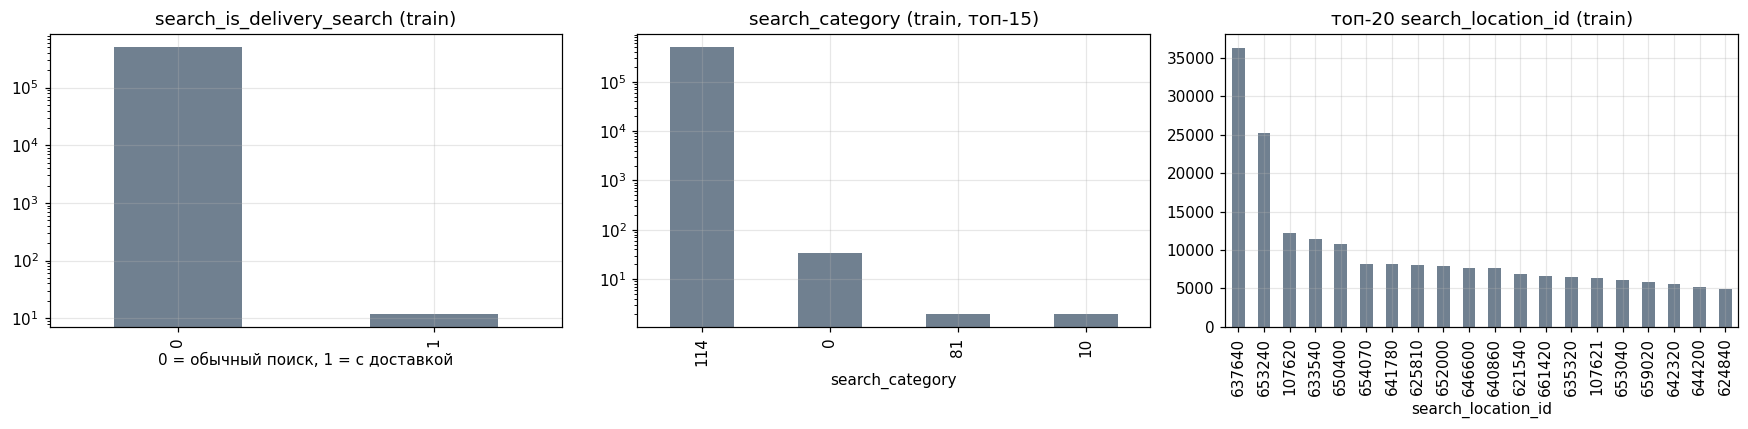

search_location_id: уникальных в train = 2782 | в benchmark_queries = 273
search_category: уникальных в train = 4 | в benchmark_queries = 2


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
train['search_is_delivery_search'].value_counts().plot(kind='bar', ax=axes[0], logy=True,
    color='slategray', title='search_is_delivery_search (train)')
axes[0].set_xlabel('0 = обычный поиск, 1 = с доставкой')
train['search_category'].value_counts().head(15).plot(kind='bar', ax=axes[1], logy=True,
    color='slategray', title='search_category (train, топ-15)')
train['search_location_id'].value_counts().head(20).plot(kind='bar', ax=axes[2],
    color='slategray', title='топ-20 search_location_id (train)')
plt.tight_layout(); plt.show()

print('search_location_id: уникальных в train =', train['search_location_id'].nunique(),
      '| в benchmark_queries =', bm_queries['search_location_id'].nunique())
print('search_category: уникальных в train =', train['search_category'].nunique(),
      '| в benchmark_queries =', bm_queries['search_category'].nunique())

## 4. Объявления (`benchmark_items`)

Цены (с проверкой аномалий), рейтинги и отзывы, флаги, категории, гео, длины текстов и n-граммы заголовков.

In [11]:
p = bm_items['item_price_f']
display(p.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame('item_price'))

anom = {
    'price <= 0': int((p <= 0).sum()),
    '0 < price < 1': int(((p > 0) & (p < 1)).sum()),
    'price > 1e6': int((p > 1e6).sum()),
    'price > 1e9': int((p > 1e9).sum()),
}
print('Аномалии цены:', anom)
print('Топ-5 самых дорогих:', sorted(p.nlargest(5).round(0).astype('int64').tolist()))
print('Топ-5 самых дешёвых (включая мусор):', sorted(p.nsmallest(5).round(0).astype('int64').tolist()))

,item_price
count,1.892120e+05
mean,1.986029e+07
std,3.730628e+09
min,-1.000000e+00
1%,-1.000000e+00
5%,-1.000000e+00
25%,3.800000e+02
50%,1.000000e+03
75%,2.500000e+03
95%,1.600000e+04


Аномалии цены: {'price <= 0': 16588, '0 < price < 1': 0, 'price > 1e6': 627, 'price > 1e9': 8}
Топ-5 самых дорогих: [444444444444, 777777777777, 777777777777, 777777777777, 777777777777]
Топ-5 самых дешёвых (включая мусор): [-1, -1, -1, -1, -1]


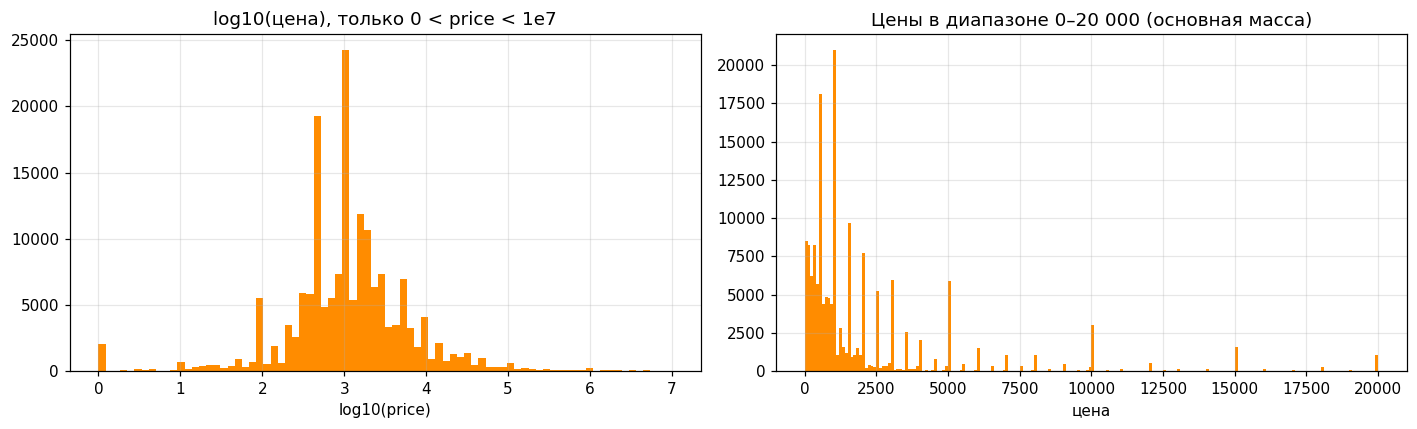

95.6% всех валидных цен — до 20 000; медиана = 1000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pp = p[(p > 0) & (p < 1e7)]
axes[0].hist(np.log10(pp), bins=80, color='darkorange')
axes[0].set_title('log10(цена), только 0 < price < 1e7')
axes[0].set_xlabel('log10(price)')

axes[1].hist(pp, bins=200, range=(0, 20000), color='darkorange')
axes[1].set_title('Цены в диапазоне 0–20 000 (основная масса)')
axes[1].set_xlabel('цена')
plt.tight_layout(); plt.show()

share_low = (pp <= 20000).mean()
print(f'{100*share_low:.1f}% всех валидных цен — до 20 000; медиана = {p.median():.0f}')

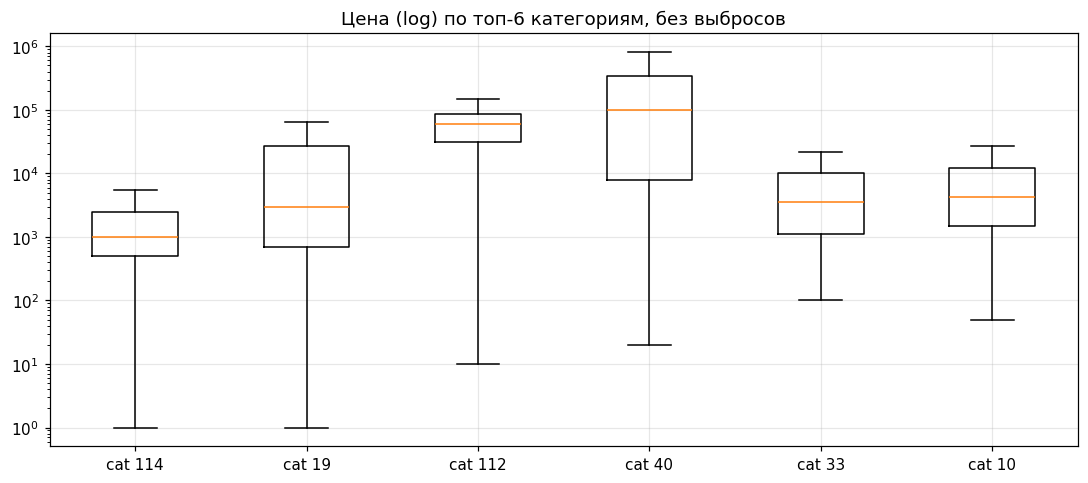

Число объявлений по топ-6 категориям: {114: 187336, 19: 357, 112: 141, 40: 122, 33: 103, 10: 98}


In [13]:
top_cats = bm_items['item_category_id'].value_counts().head(6).index.tolist()
data = []
for c in top_cats:
    d = bm_items.loc[bm_items['item_category_id'] == c, 'item_price_f']
    data.append(d[(d > 0) & (d < 1e6)].values)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot(data, showfliers=False)
ax.set_xticks(range(1, len(top_cats) + 1))
ax.set_xticklabels([f'cat {c}' for c in top_cats])
ax.set_yscale('log')
ax.set_title('Цена (log) по топ-6 категориям, без выбросов')
plt.tight_layout(); plt.show()

print('Число объявлений по топ-6 категориям:',
      dict(zip(top_cats, bm_items['item_category_id'].value_counts().head(6).tolist())))

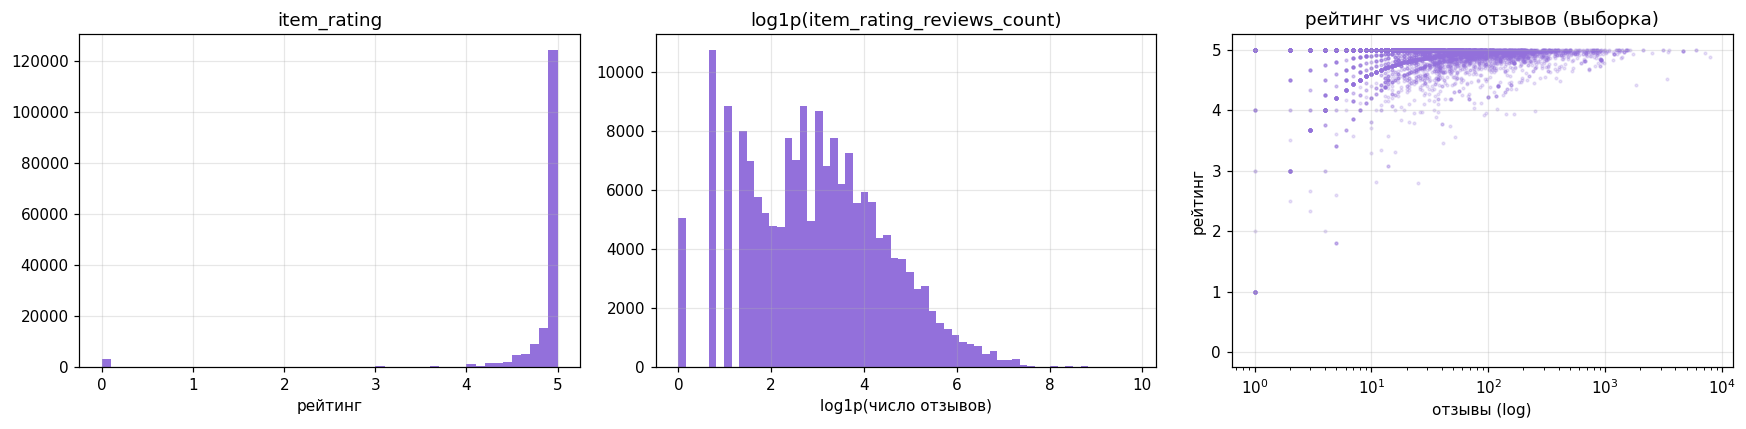

рейтинг заполнен в 90.7% строк; медиана = 5.0; доля ровно 5.0 = 49.9%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bm_items['item_rating'].hist(bins=50, ax=axes[0], color='mediumpurple')
axes[0].set_title('item_rating')
axes[0].set_xlabel('рейтинг')

np.log1p(bm_items['item_rating_reviews_count']).hist(bins=60, ax=axes[1], color='mediumpurple')
axes[1].set_title('log1p(item_rating_reviews_count)')
axes[1].set_xlabel('log1p(число отзывов)')

s = bm_items[['item_rating', 'item_rating_reviews_count']].dropna()
s = s.sample(min(8000, len(s)), random_state=0)
axes[2].scatter(s['item_rating_reviews_count'], s['item_rating'], s=3, alpha=.2, color='mediumpurple')
axes[2].set_xscale('log')
axes[2].set_title('рейтинг vs число отзывов (выборка)')
axes[2].set_xlabel('отзывы (log)'); axes[2].set_ylabel('рейтинг')
plt.tight_layout(); plt.show()

r = bm_items['item_rating']
print(f'рейтинг заполнен в {100*r.notna().mean():.1f}% строк; медиана = {r.median()}; '
      f'доля ровно 5.0 = {100*(r==5).mean():.1f}%')

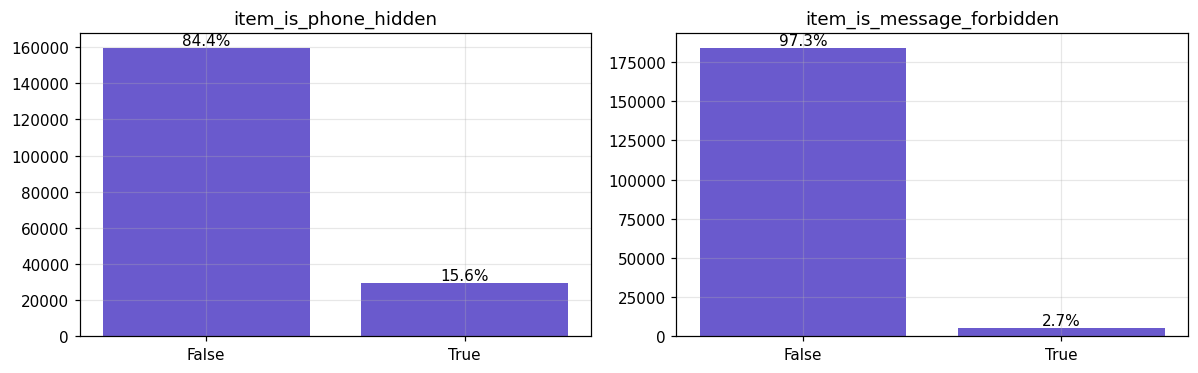

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col in zip(axes, ['item_is_phone_hidden', 'item_is_message_forbidden']):
    vc = bm_items[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color='slateblue')
    ax.set_title(col)
    for i, v in enumerate(vc.values):
        ax.text(i, v, f'{100*v/len(bm_items):.1f}%', ha='center', va='bottom')
plt.tight_layout(); plt.show()

item_category_id: уникальных = 47
item_microcat_id: уникальных = 752
item_location_id: уникальных = 2877


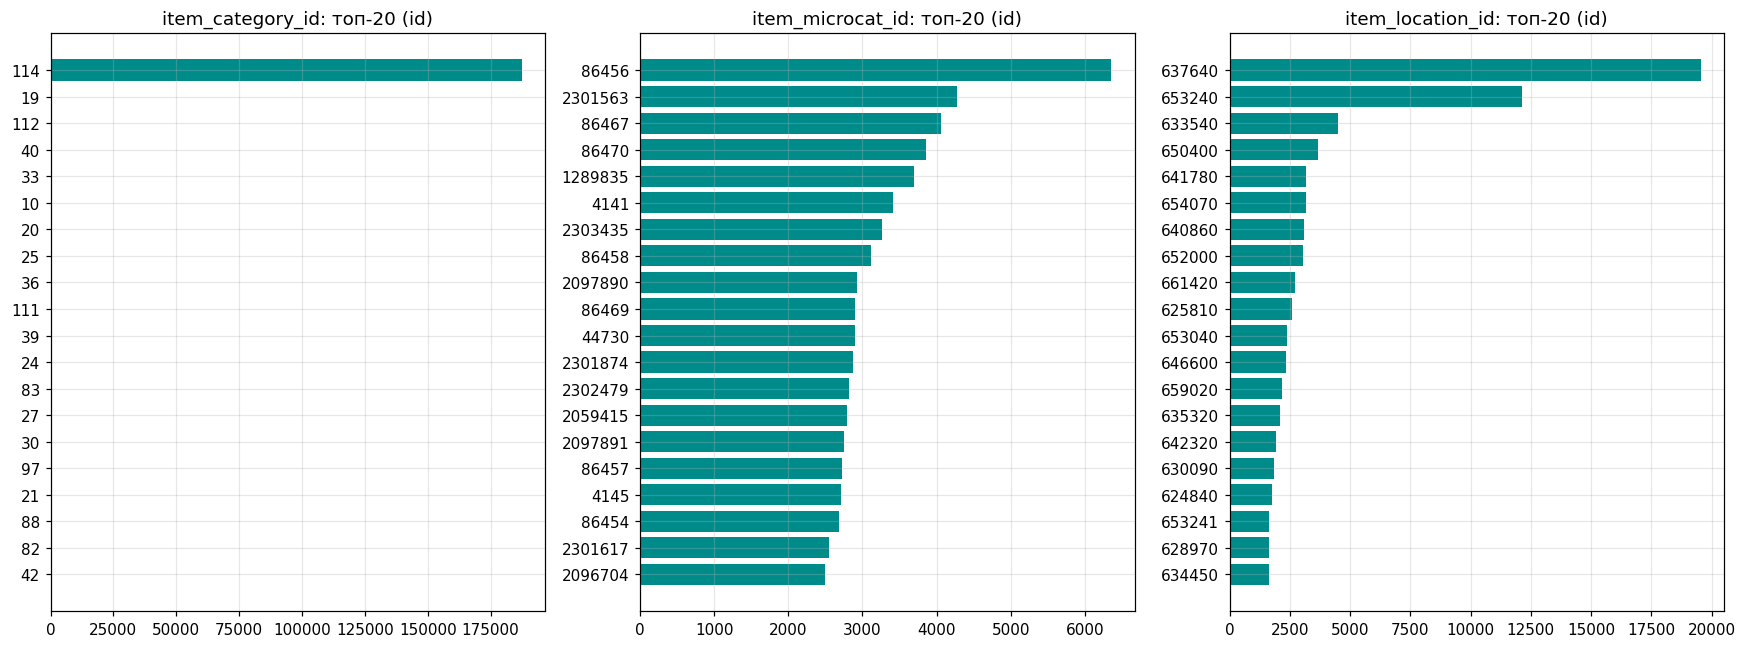

In [16]:
for col in ['item_category_id', 'item_microcat_id', 'item_location_id']:
    print(f'{col}: уникальных = {bm_items[col].nunique()}')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, col in zip(axes, ['item_category_id', 'item_microcat_id', 'item_location_id']):
    top20 = bm_items[col].value_counts().head(20)[::-1]
    ax.barh([str(x) for x in top20.index], top20.values, color='darkcyan')
    ax.set_title(f'{col}: топ-20 (id)')
plt.tight_layout(); plt.show()

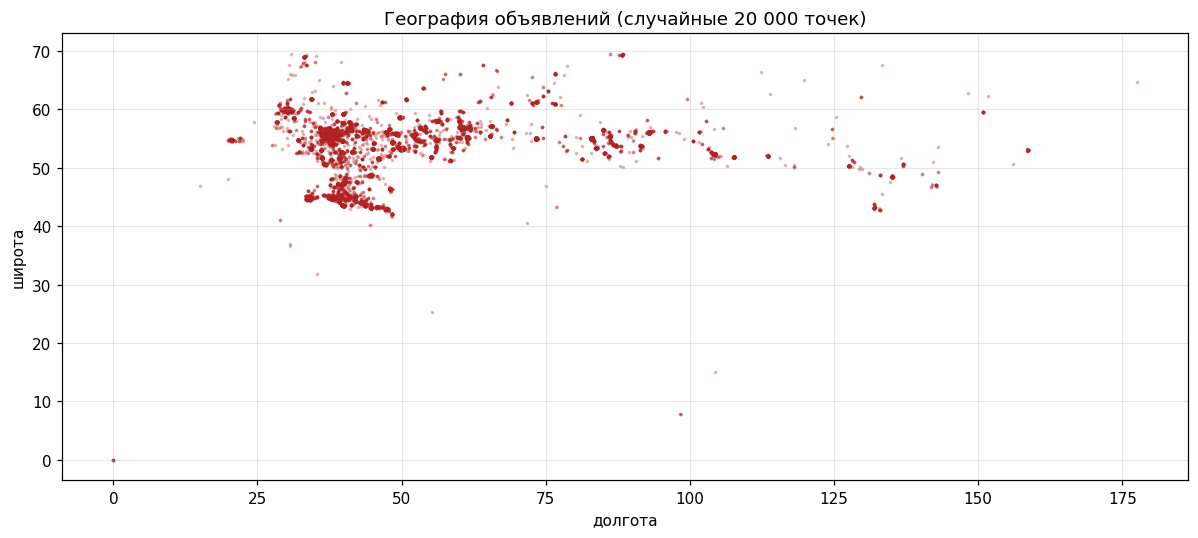

Точек с подозрительными координатами (не РФ): 152


,item_title_raw,item_price_f,item_lat_f,item_lon_f
902,Вывоз холодильников стиральных машин и плит,300.0,0.000000,0.000000
1802,Выкуп Авто Автовыкуп,550000.0,0.000000,0.000000
2896,"Обучение охрана труда, рабочие профессии",500.0,31.780432,35.238474
4392,Микроскоп в аренду,800.0,0.000000,0.000000
4639,"Свеча вольт, кукла Вуду",300.0,0.000000,0.000000


In [17]:
geo = bm_items[['item_lat_f', 'item_lon_f']].dropna()
geo = geo.sample(min(20000, len(geo)), random_state=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(geo['item_lon_f'], geo['item_lat_f'], s=2, alpha=.25, color='firebrick')
ax.set_title('География объявлений (случайные 20 000 точек)')
ax.set_xlabel('долгота'); ax.set_ylabel('широта')
plt.tight_layout(); plt.show()

# выбросы за пределами примерной географии РФ
bad = bm_items[(bm_items['item_lat_f'] < 40) | (bm_items['item_lat_f'] > 82) |
               (bm_items['item_lon_f'] < 15) | (bm_items['item_lon_f'] > 190)]
print('Точек с подозрительными координатами (не РФ):', len(bad))
display(bad[['item_title_raw', 'item_price_f', 'item_lat_f', 'item_lon_f']].head(5))

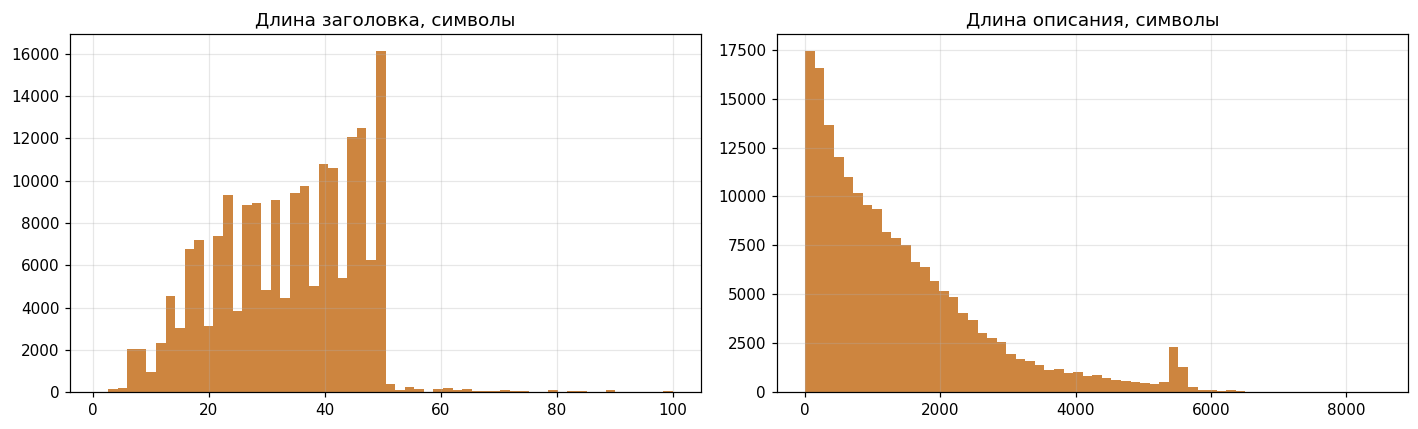

title_len: {'count': 189212.0, 'mean': 34.0, 'std': 12.0, 'min': 1.0, '25%': 24.0, '50%': 35.0, '75%': 44.0, 'max': 100.0}
desc_len : {'count': 189177.0, 'mean': 1405.0, 'std': 1284.0, 'min': 1.0, '25%': 422.0, '50%': 1054.0, '75%': 1978.0, 'max': 8494.0}


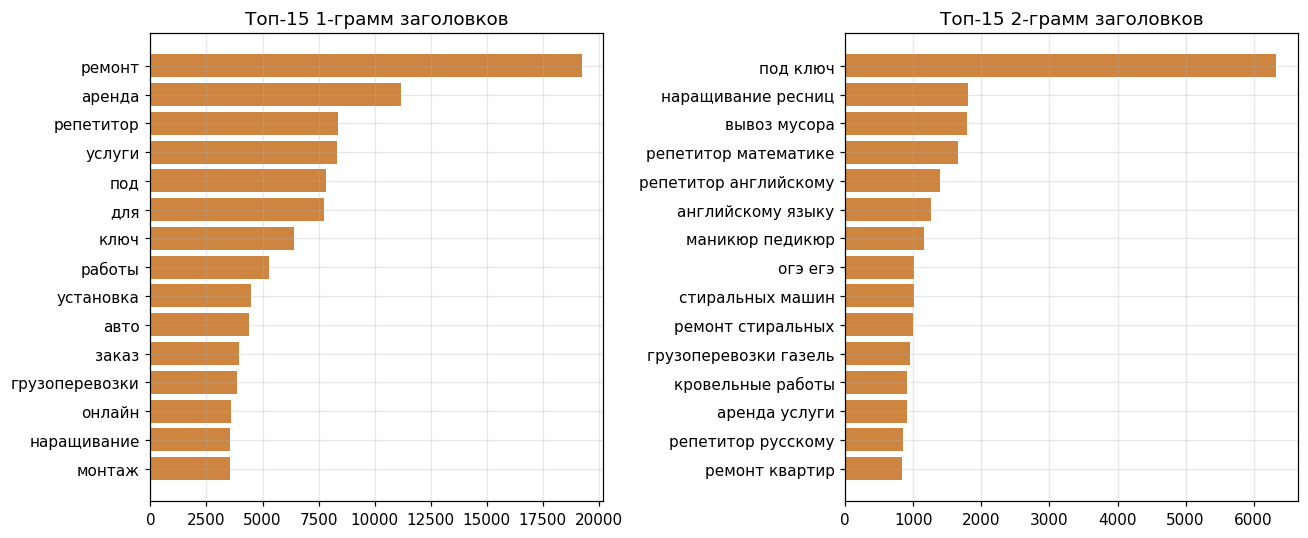

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(bm_items['title_len'].dropna(), bins=60, color='peru')
axes[0].set_title('Длина заголовка, символы')
axes[1].hist(bm_items['desc_len'].dropna(), bins=60, color='peru')
axes[1].set_title('Длина описания, символы')
plt.tight_layout(); plt.show()
print('title_len:', bm_items['title_len'].describe().round(0).to_dict())
print('desc_len :', bm_items['desc_len'].describe().round(0).to_dict())


def top_ngrams(texts, n=1, k=15):
    cnt = Counter()
    for t in texts:
        ws = re.findall(r'\w+', str(t).lower())
        ws = [w for w in ws if len(w) > 2]
        if n == 1:
            cnt.update(ws)
        else:
            cnt.update(' '.join(ws[i:i + n]) for i in range(len(ws) - n + 1))
    return cnt.most_common(k)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, n in zip(axes, [1, 2]):
    grams = top_ngrams(bm_items['item_title_raw'].dropna(), n=n, k=15)
    labels = [g for g, _ in grams][::-1]
    vals = [c for _, c in grams][::-1]
    ax.barh(labels, vals, color='peru')
    ax.set_title(f'Топ-15 {n}-грамм заголовков')
plt.tight_layout(); plt.show()

## 5. Структура пар в `train`

Группа запроса = одинаковый `search_query` + локация + категория + флаг доставки + параметры.
Смотрим: сколько объявлений в группе, дубликаты пар, пересечение с бенчмарком.

Групп запросов: 354463
count    354463.00
mean          1.40
std           2.61
min           1.00
50%           1.00
90%           2.00
99%           7.00
99.9%        25.00
max         628.00


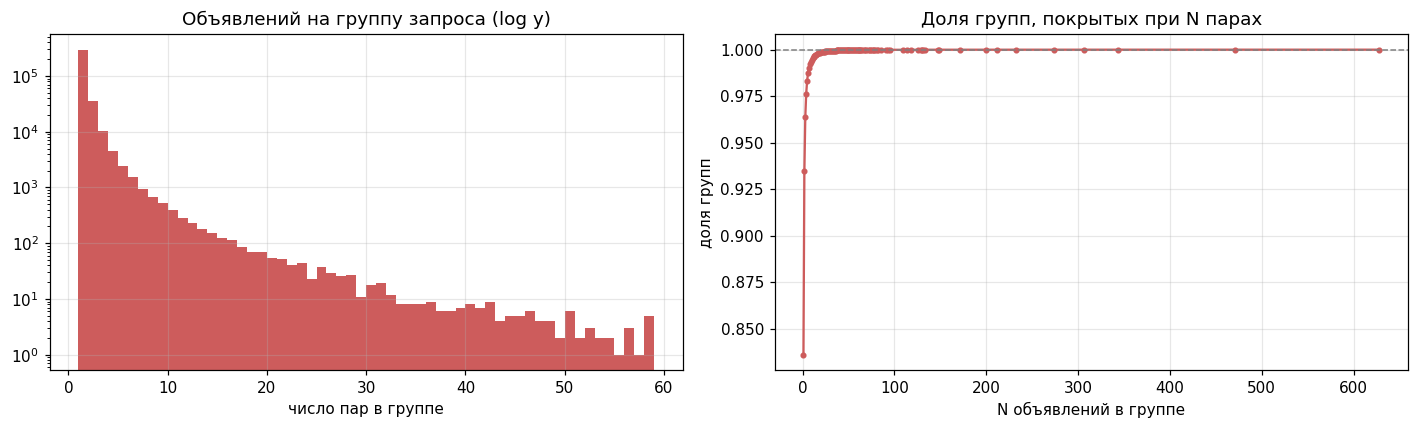

Групп с 1 объявлением: 83.6%
Топ-10 самых больших групп:


,search_query,search_location_id,search_category,search_is_delivery_search,search_infm_params_text,пар
0,вскрытие замков,646600,114,0,Тип услуги Вид услуги Ремонт и отделка,628
1,услуги эвакуатора,625810,114,0,,471
2,услуги манипулятора,625810,114,0,,344
3,маникюр,637640,114,0,"Тип услуги Маникюр, педикюр Вид услуги Красота...",307
4,услуги эвакуатора,628970,114,0,,274
5,маникюр,653240,114,0,"Тип услуги Маникюр, педикюр Вид услуги Красота...",232
6,наращивание ресниц,637640,114,0,"Тип услуги Ресницы, брови Вид услуги Красота, ...",212
7,установка кондиционеров,637640,114,0,Вид услуги Монтаж и установка техники,200
8,увеличение губ,653240,114,0,"Тип услуги Косметология Вид услуги Красота, зд...",171
9,наращивание ресниц,653240,114,0,"Тип услуги Ресницы, брови Вид услуги Красота, ...",149


In [21]:
gsz = train.groupby(GROUP_COLS, dropna=False).size()
print('Групп запросов:', len(gsz))
print(gsz.describe(percentiles=[.5, .9, .99, .999]).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(gsz, bins=np.arange(1, 60, 1), log=True, color='indianred')
axes[0].set_title('Объявлений на группу запроса (log y)')
axes[0].set_xlabel('число пар в группе')

cum = gsz.value_counts().sort_index().cumsum() / len(gsz)
axes[1].plot(cum.index, cum.values, marker='.', color='indianred')
axes[1].axhline(1.0, ls='--', c='gray', lw=1)
axes[1].set_title('Доля групп, покрытых при N парах')
axes[1].set_xlabel('N объявлений в группе'); axes[1].set_ylabel('доля групп')
plt.tight_layout(); plt.show()

print(f'Групп с 1 объявлением: {100*(gsz==1).mean():.1f}%')
print('Топ-10 самых больших групп:')
big = gsz.sort_values(ascending=False).head(10).rename('пар').reset_index()
big['search_query'] = big['search_query'].str.slice(0, 50)
display(big)

In [22]:
dup_mask = train.duplicated(subset=GROUP_COLS + ['item_id'], keep=False)
print(f'Строк с повторяющейся парой (группа запроса, item_id): {dup_mask.sum()} ({100*dup_mask.mean():.1f}%)')
uniq_pairs = train.drop_duplicates(subset=GROUP_COLS + ['item_id'])
print(f'Уникальных пар (группа, item): {len(uniq_pairs)} (было {len(train)} строк)')
display(train.loc[dup_mask, GROUP_COLS + ['item_id', 'item_title_raw', 'item_price_f']].head(5))

Строк с повторяющейся парой (группа запроса, item_id): 48533 (9.8%)
Уникальных пар (группа, item): 467054 (было 497673 строк)


,search_query,search_location_id,search_category,search_is_delivery_search,search_infm_params_text,item_id,item_title_raw,item_price_f
8,выкуп компьютеров,661420,114,0,Вид услуги,1806b31ef88a665f,"Выкуп пк, ноутбуков,приставок",100000.0
42,навесы из поликарбоната,629840,114,0,Тип услуги Другое Вид услуги Строительство,4838e5257784205a,Навесы/навес/навесы из поликарбоната/изготовление,1000.0
44,трактор,623130,114,0,,c5039719c0877478,"Трактор, экскаватор погрузчик",3500.0
51,автоэлектрик,628500,114,0,"Вид услуги Автосервис, аренда Тип услуги Автос...",c55e238dbfbfca0c,Автоэлектрик выезд на место,500.0
57,услуги эвакуатора,633540,114,0,,4a3c48aef4ca619d,Эвакуатор. Услуги эвакуатора,60.0


,что сравниваем,пересечение,всего в benchmark,%
0,товары benchmark есть в train,18142,189212,9.6
1,тексты запросов benchmark есть в train,907,2452,37.0


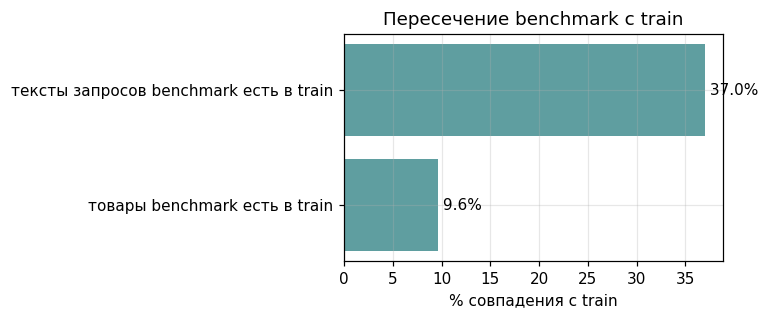

In [23]:
tr_items_set = set(train['item_id'])
bi_set = set(bm_items['item_id'])
tr_qtexts = set(train['search_query'])
bq_texts = set(bm_queries['search_query'])

rows = pd.DataFrame([
    {'что сравниваем': 'товары benchmark есть в train',
     'пересечение': len(bi_set & tr_items_set), 'всего в benchmark': len(bi_set)},
    {'что сравниваем': 'тексты запросов benchmark есть в train',
     'пересечение': len(bq_texts & tr_qtexts), 'всего в benchmark': len(bq_texts)},
])
rows['%'] = (100 * rows['пересечение'] / rows['всего в benchmark']).round(1)
display(rows)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(rows['что сравниваем'], rows['%'], color='cadetblue')
for i, v in enumerate(rows['%']):
    ax.text(v, i, f' {v}%', va='center')
ax.set_xlabel('% совпадения с train')
ax.set_title('Пересечение benchmark с train')
plt.tight_layout(); plt.show()

## 6. Числовые корреляции (train)

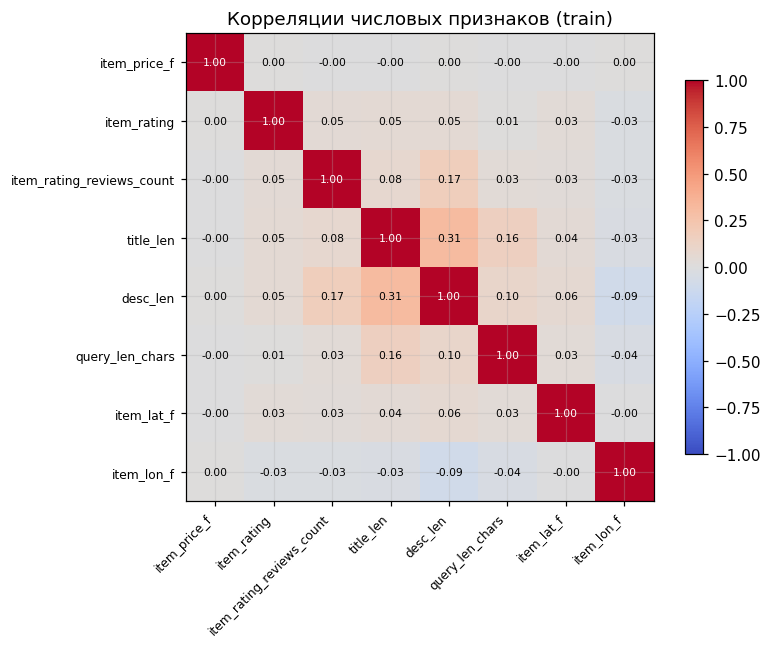

,item_price_f,item_rating,item_rating_reviews_count,title_len,desc_len,query_len_chars,item_lat_f,item_lon_f
item_price_f,1.000,0.000,-0.001,-0.002,0.003,-0.003,-0.003,0.000
item_rating,0.000,1.000,0.046,0.048,0.051,0.006,0.034,-0.025
item_rating_reviews_count,-0.001,0.046,1.000,0.077,0.169,0.032,0.026,-0.026
title_len,-0.002,0.048,0.077,1.000,0.305,0.156,0.040,-0.035
desc_len,0.003,0.051,0.169,0.305,1.000,0.101,0.057,-0.091
query_len_chars,-0.003,0.006,0.032,0.156,0.101,1.000,0.031,-0.044
item_lat_f,-0.003,0.034,0.026,0.040,0.057,0.031,1.000,-0.001
item_lon_f,0.000,-0.025,-0.026,-0.035,-0.091,-0.044,-0.001,1.000


In [24]:
num_cols = ['item_price_f', 'item_rating', 'item_rating_reviews_count',
            'title_len', 'desc_len', 'query_len_chars', 'item_lat_f', 'item_lon_f']
corr = train[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > .5 else 'black')
fig.colorbar(im, ax=ax, shrink=.8)
ax.set_title('Корреляции числовых признаков (train)')
plt.tight_layout(); plt.show()

display(corr.round(3))

## 7. Авто-сводка

Ключевые числа пересчитываются из загруженных данных — ячейка ниже собирает их в один список выводов.

In [25]:
gsz2 = train.groupby(GROUP_COLS, dropna=False).size()
dup_pairs = int(train.duplicated(subset=GROUP_COLS + ['item_id']).sum())
p = bm_items['item_price_f']

summary = [
    ('Размеры', f'train {len(train):,} строк × {train.shape[1]} колонок; benchmark_items {len(bm_items):,}; benchmark_queries {len(bm_queries):,}'),
    ('Структура пар', f'{len(gsz2):,} групп запросов; медиана {gsz2.median():.0f} объявлений на группу, максимум {gsz2.max()}; {100*(gsz2==1).mean():.1f}% групп с 1 объявлением'),
    ('Дубликаты', f'{dup_pairs:,} повторяющихся пар (группа запроса, item) — {100*dup_pairs/len(train):.1f}% train'),
    ('Пересечение с benchmark', f'товары: {len(bi_set & tr_items_set):,} из {len(bi_set):,} ({100*len(bi_set & tr_items_set)/len(bi_set):.1f}%); тексты запросов: {len(bq_texts & tr_qtexts)} из {len(bq_texts)} ({100*len(bq_texts & tr_qtexts)/len(bq_texts):.1f}%)'),
    ('Цены', f'медиана {p.median():.0f}; аномалий price<=0: {(p<=0).sum()}; price>1e9: {(p>1e9).sum()} — чистить перед моделированием'),
    ('Рейтинги', f'заполнены в {100*bm_items["item_rating"].notna().mean():.1f}% объявлений; медиана {bm_items["item_rating"].median()}; {100*(bm_items["item_rating"]==5).mean():.1f}% имеют ровно 5.0'),
    ('Параметры поиска', f'в train у {100*tr_has.mean():.1f}% запросов есть infm_params_text'),
    ('Категории/гео', f'item категорий: {bm_items["item_category_id"].nunique()}, микрокатегорий: {bm_items["item_microcat_id"].nunique()}, локаций: {bm_items["item_location_id"].nunique()}'),
    ('Доставка', f'в train {int(train["search_is_delivery_search"].sum())} пар с is_delivery=1 из {len(train):,} — флаг почти константный'),
]
for title, txt in summary:
    print(f'• {title}: {txt}')

• Размеры: train 497,673 строк × 26 колонок; benchmark_items 189,212; benchmark_queries 2,452
• Структура пар: 354,463 групп запросов; медиана 1 объявлений на группу, максимум 628; 83.6% групп с 1 объявлением
• Дубликаты: 30,619 повторяющихся пар (группа запроса, item) — 6.2% train
• Пересечение с benchmark: товары: 18,142 из 189,212 (9.6%); тексты запросов: 907 из 2452 (37.0%)
• Цены: медиана 1000; аномалий price<=0: 16588; price>1e9: 8 — чистить перед моделированием
• Рейтинги: заполнены в 90.7% объявлений; медиана 5.0; 49.9% имеют ровно 5.0
• Параметры поиска: в train у 67.0% запросов есть infm_params_text
• Категории/гео: item категорий: 47, микрокатегорий: 752, локаций: 2877
• Доставка: в train 12 пар с is_delivery=1 из 497,673 — флаг почти константный


## Что делать с выводами

- **Чистка цен:** убрать/заменить `price <= 0` и экстремумы (>1e9) до любого моделирования; для моделей, чувствительных к масштабу, — лог-преобразование.
- **Дубликаты пар:** решить, схлопывать ли повторные (группа, item) — это влияет на функцию потерь и метрики.
- **Дисбаланс локаций/категорий:** при валидации стратифицировать сплиты по `search_category`/`search_location_id`.
- **Тексты:** длины и n-граммы показывают, что запросы короткие и одно-двухсловные — токенизация/эмбеддинги должны это учитывать.
- **Почти константные флаги** (`is_delivery_search`, категории вне 114) — почти не несут сигнала в train.